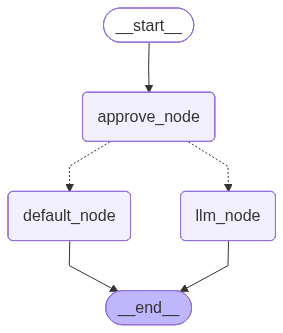

{'topic': '菊花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='91edf41ecf736a242c18fd61d40ad5b4')]}


In [2]:
from time import sleep
from typing import TypedDict, Literal

from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from langchain_deepseek import ChatDeepSeek

from dotenv import load_dotenv
load_dotenv(override=True)

model =ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking":{
            "type":"disabled"
        }
    }
)

#1. 声明状态
class OverAllState(TypedDict):
    topic:str
    poem:str
    is_approved:bool

#2. 声明节点
def approve_node(state:OverAllState) -> Command[Literal["llm_node","default_node"]]:
    is_approved = interrupt("是否同意调用模型?")
    goto = "llm_node" if is_approved else "default_node"
    return Command(
        goto=goto,
        update={"is_approved":is_approved}
    )

def llm_node(state:OverAllState) -> OverAllState:
    topic = state["topic"]
    res = model.invoke([HumanMessage(content=f"帮我写一首关于{topic}主题的七言绝句,只写诗句,不需要赏析")]).content

    return {
        "poem":res
    }

def default_node(state:OverAllState) -> OverAllState:
    return {
        "poem":"请求被拒绝"
    }

#3. 构建图
builder = StateGraph(state_schema=OverAllState)

builder.add_node("approve_node",approve_node)
builder.add_node("llm_node",llm_node)
builder.add_node("default_node",default_node)
builder.add_edge(START,"approve_node")
builder.add_edge("llm_node",END)
builder.add_edge("default_node",END)

#4. 添加检查点后端
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

from IPython.display import display
display(graph)

#5. 首次执行 -> 触发中断
config = {"configurable":{"thread_id":"234"}}
interrupt_res = graph.invoke({"topic":"菊花"},config=config)
print(interrupt_res)



In [3]:
#6. 人工审核
user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'
# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config)
print(approved_res)


{'topic': '菊花', 'poem': '《咏菊》\n西风猎猎卷霜华，独抱秋心隐士家。\n冷艳不争桃李色，寒香偏入野人茶。', 'is_approved': True}


In [4]:
#7. 审核不通过
config1 = {"configurable":{"thread_id":"456"}}
interrupt_res = graph.invoke({"topic":"牡丹花"},config=config1)
print(interrupt_res)

user_approved = input("是否同意调用模型?(y/n)").strip().lower() == 'y'

# 重新调用图
approved_res = graph.invoke(Command(resume=user_approved),config=config1)
print(approved_res)

{'topic': '牡丹花', '__interrupt__': [Interrupt(value='是否同意调用模型?', id='47958afc1277b7ce6bf850a5f27f2e46')]}
{'topic': '牡丹花', 'poem': '请求被拒绝', 'is_approved': False}
